In [ ]:
!git clone https://github.com/laukamkit/capstone_project_GroupA.git

Cloning into 'capstone_project_GroupA'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 759 (delta 4), reused 6 (delta 2), pack-reused 727 (from 2)
Receiving objects: 100% (759/759), 285.20 MiB | 15.82 MiB/s, done.
Resolving deltas: 100% (332/332), done.
Updating files: 100% (74/74), done.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from pathlib import Path

repo_path = "capstone_project_GroupA"
nsw_path = os.path.join(repo_path, "data", "NSW")

TRAIN_SCALED_PATH = os.path.join(nsw_path, "train_scaled.csv")
VAL_SCALED_PATH   = os.path.join(nsw_path, "val_scaled.csv")
TEST_SCALED_PATH  = os.path.join(nsw_path, "test_scaled.csv")
TRAIN_RAW_PATH    = os.path.join(nsw_path, "train.csv")
VAL_RAW_PATH   = os.path.join(nsw_path, "validation.csv")
TEST_RAW_PATH  = os.path.join(nsw_path, "test.csv")

# results directory
OUTPUT_DIR = os.path.join(repo_path, "output", "patchtst_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================================
# 2. Read CSV
# =========================================================
train_scaled_df = pd.read_csv(TRAIN_SCALED_PATH)
val_scaled_df   = pd.read_csv(VAL_SCALED_PATH)
test_scaled_df  = pd.read_csv(TEST_SCALED_PATH)
train    = pd.read_csv(TRAIN_RAW_PATH)
validation    = pd.read_csv(VAL_RAW_PATH)
test    = pd.read_csv(TEST_RAW_PATH)

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
validation.head()

Train shape: (112651, 8)
Validation shape: (37550, 8)
Test shape: (37552, 56)


,DATETIME,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
0,2016-12-04 09:30:00,7682.19,7762.16,8010.04,8110.72,24.4,336.151259,5.423888e+06
1,2016-12-04 10:00:00,7643.18,7586.20,7783.98,7972.58,26.0,230.173803,2.543039e+06
2,2016-12-04 10:30:00,7817.04,7567.46,7726.09,7999.13,26.8,254.787494,3.116000e+06
3,2016-12-04 11:00:00,7950.21,7388.54,7583.57,7876.98,26.9,278.677440,3.727734e+06
4,2016-12-04 11:30:00,8069.70,7187.68,7412.39,7826.86,27.8,267.758513,3.441342e+06


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from pathlib import Path

# Set 30-minute frequency for time series modelling
# Convert 'DATETIME' to datetime objects and set as index for all dataframes

def prepare_dataframe_for_timeseries(df):
    # If 'DATETIME' is already the index and is a DatetimeIndex, assume it's processed
    if isinstance(df.index, pd.DatetimeIndex) and df.index.name == 'DATETIME':
        pass
    # If 'DATETIME' is a column, process it
    elif 'DATETIME' in df.columns:
        df["DATETIME"] = pd.to_datetime(df["DATETIME"])
        df = df.set_index("DATETIME")
    else:
        # If 'DATETIME' is not a column, but the index is not named 'DATETIME'
        # or is not a DatetimeIndex, it's an unexpected state.
        # In this scenario, it's safer to assume the initial load wasn't correct.
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index()
            if 'DATETIME' in df.columns:
                df["DATETIME"] = pd.to_datetime(df["DATETIME"])
                df = df.set_index("DATETIME")
            else:
                raise KeyError(
                    "The 'DATETIME' column is not found after resetting index. "
                    "Please ensure the raw data is loaded correctly by re-running the data loading cell (`_d2M6O8QS-le`)."
                )
        else:
            raise KeyError(
                "The 'DATETIME' column is not found, nor is it set as the index named 'DATETIME'. "
                "Please ensure the raw data is loaded correctly by re-running the data loading cell (`_d2M6O8QS-le`)."
            )

    df = df.sort_index()
    # Only set freq if the index is DatetimeIndex
    if isinstance(df.index, pd.DatetimeIndex):
        df.index.freq = '30min'
    return df


train = prepare_dataframe_for_timeseries(train)
validation = prepare_dataframe_for_timeseries(validation)
test = prepare_dataframe_for_timeseries(test)

train.index.to_series().diff().value_counts().head()

# Target variable
y_train = train['TOTALDEMAND']
y_val = validation['TOTALDEMAND']
y_test = test['TOTALDEMAND']

# Exogenous variables
exog_vars = ['TEMPERATURE']

X_train = train[exog_vars]
X_val = validation[exog_vars]
X_test = test[exog_vars]

# Clean and align training data
combined_train = pd.concat([y_train, X_train], axis=1).dropna()

y_train_clean = combined_train['TOTALDEMAND']
X_train_clean = combined_train[['TEMPERATURE']]

# Forecast horizons
horizons = [48]
window_start = 100 + 336



In [ ]:
def run_forecast(model_results, X_test, y_test, window_start, horizon):
    """
    Generate forecast and calculate error metrics for a given horizon.
    """
    y_actual = y_test.iloc[window_start:window_start + horizon]
    X_exog = X_test.iloc[window_start:window_start + horizon]

    forecast = model_results.get_forecast(
        steps=horizon,
        exog=X_exog
    )

    y_pred = forecast.predicted_mean

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mse = mean_squared_error(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)

    return y_actual, y_pred, rmse, mse, mae


def plot_forecast(y_actual, y_pred, provided_forecast, horizon, title):
    plt.figure(figsize=(10, 5))

    plt.plot(range(horizon), y_actual.values, label='Actual Demand')
    plt.plot(range(horizon), y_pred.values, label=title)

    if provided_forecast is not None:
        plt.plot(range(horizon), provided_forecast.values, label='Provided Forecast')

    plt.title(f'{horizon}-step Forecast Comparison')
    plt.xlabel('Step Ahead')
    plt.ylabel('Electricity Demand')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
train_small = train.iloc[-20000:].copy()

y_train = train_small["TOTALDEMAND"]
X_train = train_small[["TEMPERATURE"]]

combined_train = pd.concat([y_train, X_train], axis=1).dropna()
y_train_clean = combined_train["TOTALDEMAND"]
X_train_clean = combined_train[["TEMPERATURE"]]

model_SARIMAX = SARIMAX(
    y_train_clean,
    exog=X_train_clean,
    order=(1, 1, 0),
    seasonal_order=(0, 1, 0, 48),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results_SARIMAX = model_SARIMAX.fit(disp=False, maxiter=20)

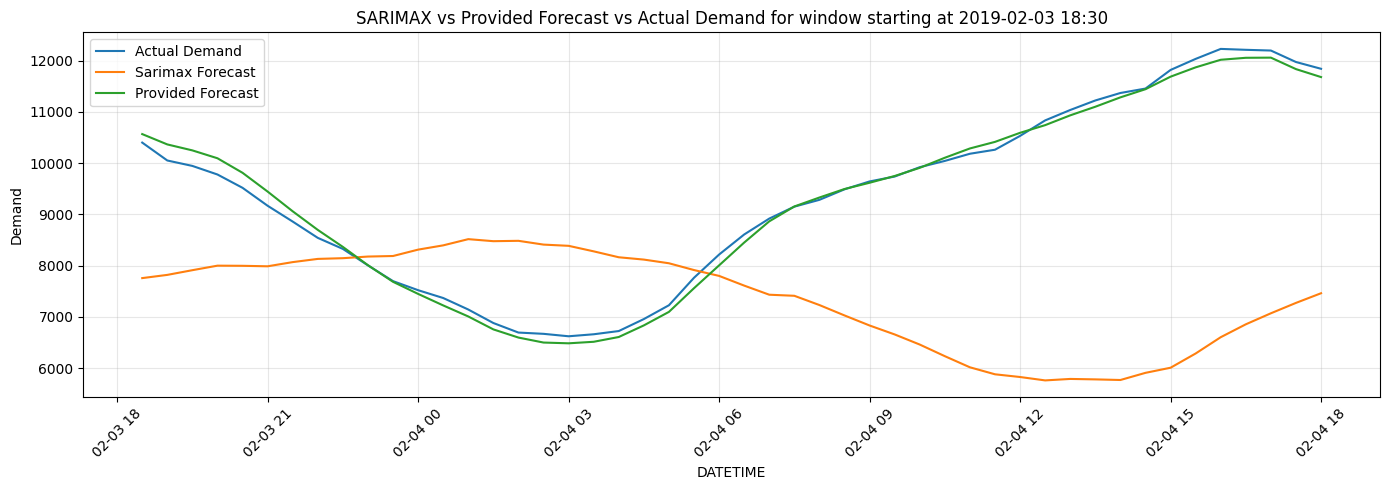


=== All Window Comparison Table ===


,Model,RMSE,MAE
0,Sarimax (all windows),3242.290191,2663.582124
1,Provided Forecast (all windows),271.898098,175.380397


In [ ]:
# ---------------------------------
# 7. Sarimax model
# ---------------------------------

SARIMAX_results = {}

for h in horizons:
    y_actual, y_pred, rmse, mse, mae = run_forecast(results_SARIMAX, X_test, y_test, window_start, h)
    SARIMAX_results[h] = (y_actual, y_pred, rmse, mse, mae)

h = 48
y_actual, y_pred, rmse_sarimax, mse_sarimax, mae_sarimax = SARIMAX_results[h]
window_df = test_plot.loc[y_actual.index].copy()
provided_forecast_series = np.array([
    window_df.iloc[i][f"P{i+1:02d}"] for i in range(48)
    ], dtype=np.float32)

# ---------------------------------
# 8. Plot
# ---------------------------------

plot_df = pd.DataFrame({
    "DATETIME": y_actual.index,
    "Actual_Demand": y_actual.values,
    "Sarimax_Forecast": y_pred.values,
    "Provided_Forecast": provided_forecast_series
})

plt.figure(figsize=(14, 5))
plt.plot(plot_df["DATETIME"], plot_df["Actual_Demand"], label="Actual Demand")
plt.plot(plot_df["DATETIME"], plot_df["Sarimax_Forecast"], label="Sarimax Forecast")
plt.plot(plot_df["DATETIME"], plot_df["Provided_Forecast"], label="Provided Forecast")

plt.title(f"SARIMAX vs Provided Forecast vs Actual Demand for window starting at {y_actual.index[0].strftime('%Y-%m-%d %H:%M')}")
plt.xlabel("DATETIME")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------
# 9. ALL windows comparison
# ---------------------------------

p_cols = [f"P{i:02d}" for i in range(1, 49)]

# Prepare test dataframe
test_all = test.copy()

if "DATETIME" in test_all.columns:
    test_all["DATETIME"] = pd.to_datetime(test_all["DATETIME"])
else:
    test_all.index = pd.to_datetime(test_all.index)
    test_all = test_all.reset_index().rename(columns={"index": "DATETIME"})

test_all = test_all.sort_values("DATETIME").reset_index(drop=True)

# Assuming horizon is 48 based on P01-P48 columns
horizon = 48
# Calculate n_windows based on the available test data and horizon
n_windows = len(test_all) - horizon + 1

# Use lists to collect arrays for concatenation after the loop
actual_all_list = []
provided_all_list = []

for w in range(n_windows):

    # locate corresponding rows in test table
    start_row = w
    end_row = start_row + horizon

    window_df = test_all.iloc[start_row:end_row].copy()
    window_df["DATETIME"] = pd.to_datetime(window_df["DATETIME"])
    window_df = window_df.set_index("DATETIME")

    # Collect actual values for this window
    actual_seq = window_df['TOTALDEMAND'].values
    actual_all_list.append(actual_seq)

    # diagonal extraction for provided forecast
    provided_seq = np.array([
        window_df.iloc[i][f"P{i+1:02d}"] for i in range(horizon)
    ], dtype=np.float32)

    # collect provided forecasts
    provided_all_list.append(provided_seq)

# flatten everything after the loop
actual_all = np.concatenate(actual_all_list)
provided_all = np.concatenate(provided_all_list)

# ---------------------------------
# 10. Metrics
# ---------------------------------

# Placeholder values for PatchTST metrics as they are not calculated in this notebook yet
rmse_patch_all = np.nan # Not available
mae_patch_all = np.nan # Not available

rmse_provided_all = np.sqrt(mean_squared_error(actual_all, provided_all))
mae_provided_all = mean_absolute_error(actual_all, provided_all)

all_window_comparison_df = pd.DataFrame({
    "Model": ["Sarimax (all windows)", "Provided Forecast (all windows)"],
    "RMSE": [rmse_sarimax, rmse_provided_all],
    "MAE": [mae_sarimax, mae_provided_all]
})

print("\n=== All Window Comparison Table ===")
display(all_window_comparison_df)